In [1]:
%load_ext autoreload
%autoreload 2

# Model Training: New Binary Classification Task

`Task Description: Predict whether a client will spend outside their wallet in the next 30 days.`

In [2]:
import gc
import os
from warnings import filterwarnings

filterwarnings("ignore")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [3]:
import torch
from relbench.datasets import get_dataset
from relbench.modeling.graph import make_pkey_fkey_graph
from relbench.modeling.utils import get_stype_proposal
from torch_frame.config.text_embedder import TextEmbedderConfig
from torch_geometric import seed_everything

In [4]:
from experiments.model_training.training.models.hgt_model import HGTModel
from experiments.model_training.training.models.sage_model import SAGEModel
from experiments.model_training.training.text_embedder import TextEmbedder
from experiments.model_training.training.trainer import Trainer
from experiments.model_training.utils import (
    compute_pos_weight,
    get_device,
    load_config,
    make_loaders,
    patched_to_unix_time,
)

In [5]:
import relbench.modeling.graph
import relbench.modeling.utils

relbench.modeling.graph.to_unix_time = patched_to_unix_time
relbench.modeling.utils.to_unix_time = patched_to_unix_time

In [6]:
from predql_tasks.tasks import SeznamClientOutOfWalletTmpTask

In [7]:
seed_everything(42)
device = get_device()
config = load_config("config.yml")
cache_dir = "./.cache_predql"
dataset_name = "ctu-seznam"
task_name = "seznam_out_of_wallet_tmp"

Using device: cuda


In [8]:
dataset = get_dataset(dataset_name, download=False)
task = SeznamClientOutOfWalletTmpTask()
db = dataset.get_db()

Loading Database object from /home/kolesiko/.cache/relbench/ctu-seznam/db...
Done in 0.16 seconds.


In [9]:
col_to_stype_dict = get_stype_proposal(db)
col_to_stype_dict

{'probehnuto_mimo_penezenku': {'__PK__': <stype.numerical: 'numerical'>,
  'client_id': <stype.numerical: 'numerical'>,
  'Month_Year': <stype.timestamp: 'timestamp'>,
  'probehla_inzerce_mimo_penezenku': <stype.categorical: 'categorical'>,
  'FK_client_client_id': <stype.numerical: 'numerical'>},
 'dobito': {'__PK__': <stype.numerical: 'numerical'>,
  'client_id': <stype.numerical: 'numerical'>,
  'month_year_datum_transakce': <stype.timestamp: 'timestamp'>,
  'sluzba': <stype.categorical: 'categorical'>,
  'kc_dobito': <stype.numerical: 'numerical'>,
  'FK_client_client_id': <stype.numerical: 'numerical'>},
 'probehnuto': {'__PK__': <stype.numerical: 'numerical'>,
  'client_id': <stype.numerical: 'numerical'>,
  'month_year_datum_transakce': <stype.timestamp: 'timestamp'>,
  'sluzba': <stype.categorical: 'categorical'>,
  'kc_proklikano': <stype.numerical: 'numerical'>,
  'FK_client_client_id': <stype.numerical: 'numerical'>},
 'client': {'__PK__': <stype.numerical: 'numerical'>,
  '

In [10]:
model_name = config["shared"]["text_embedder_model_name"]
batch_size = config["shared"]["batch_size"]

In [11]:
text_embedder = TextEmbedderConfig(
    text_embedder=TextEmbedder(
        model_name=model_name,
        device="cpu",
        cache_dir=cache_dir), batch_size=batch_size
)

data, col_stats_dict = make_pkey_fkey_graph(
    db,
    col_to_stype_dict,
    text_embedder,
    cache_dir=os.path.join(cache_dir, dataset_name)
)

data

HeteroData(
  probehnuto_mimo_penezenku={
    tf=TensorFrame([588990, 3]),
    time=[588990],
  },
  dobito={
    tf=TensorFrame([501626, 4]),
    time=[501626],
  },
  probehnuto={
    tf=TensorFrame([1321324, 4]),
    time=[1321324],
  },
  client={ tf=TensorFrame([73447, 2]) },
  (probehnuto_mimo_penezenku, f2p_FK_client_client_id, client)={ edge_index=[2, 588990] },
  (client, rev_f2p_FK_client_client_id, probehnuto_mimo_penezenku)={ edge_index=[2, 588990] },
  (dobito, f2p_FK_client_client_id, client)={ edge_index=[2, 501396] },
  (client, rev_f2p_FK_client_client_id, dobito)={ edge_index=[2, 501396] },
  (probehnuto, f2p_FK_client_client_id, client)={ edge_index=[2, 1321023] },
  (client, rev_f2p_FK_client_client_id, probehnuto)={ edge_index=[2, 1321023] }
)

In [12]:
loader_dict, _, _ = make_loaders(
    data,
    task,
    batch_size,
    num_neighbors=config["shared"]["num_neighbors"]
)

Loading Database object from /home/kolesiko/.cache/relbench/ctu-seznam/db...
Done in 0.09 seconds.
Loading Database object from /home/kolesiko/.cache/relbench/ctu-seznam/db...
Done in 0.09 seconds.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [13]:
task_type = task.task_type

in_channels = config["shared"]["in_channels"]
learning_rate = config["shared"]["learning_rate"]
dropout = config["shared"]["dropout"]
num_epochs = config["shared"]["num_epochs"]
num_runs = config["shared"]["num_runs"]

mlp_config = config["mlp_head"]
mlp_config["out_channels"] = 1

pos_weight = compute_pos_weight(task)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Class weights computed: pos_weight=1.00


## SAGE


MODEL INFO:
Model name: SAGE
Number of parameters: 1769217


STARTING RUN 1/5


Evaluating: 100%|██████████| 528/528 [00:04<00:00, 128.75it/s]


Epoch 1/30 | Train Loss: 0.5995 | Train accuracy: 0.6461
Epoch 1/30 |   Val Loss: 0.4946 |   Val accuracy: 0.9752
New best model found with Val accuracy: 0.9752


Evaluating: 100%|██████████| 528/528 [00:03<00:00, 133.91it/s]


New best model found with Val accuracy: 0.9757


...

Evaluating: 100%|██████████| 528/528 [00:03<00:00, 141.23it/s]


!!! No improvement in Val accuracy for 10 epochs (Early stopping at epoch 14) !!!


Evaluating: 100%|██████████| 569/569 [00:04<00:00, 139.89it/s]


Run 5/5 | Final Train Metrics: {'accuracy': 0.6469836592382779, 'roc_auc': 0.7022876768435049, 'average_precision': 0.5489099384423848, 'f1': 0.10984421441016706, 'loss': 0.5884044779720436}
Run 5/5 | Final Val Metrics: {'accuracy': 0.974352711284807, 'roc_auc': 0.737755611978984, 'average_precision': 0.13232785674856196, 'f1': 0.3018335684062059, 'loss': 0.45707550641786293}
Run 5/5 | Final Test Metrics: {'accuracy': 0.9747833913933722, 'roc_auc': 0.7455691225840958, 'average_precision': 0.1324269634069941, 'f1': 0.2988154375238823, 'loss': 0.45693158033971415}
FINISHED RUN 5/5


FINAL STATS OVER 5 RUNS

[TRAIN] Metrics:
  Accuracy: 0.6460 ± 0.0011
  Roc_auc: 0.7017 ± 0.0008
  Average_precision: 0.5478 ± 0.0011
  F1: 0.1002 ± 0.0098
  Loss: 0.5881 ± 0.0008

[VAL] Metrics:
  Accuracy: 0.9764 ± 0.0016
  Roc_auc: 0.7373 ± 0.0015
  Average_precision: 0.1282 ± 0.0037
  F1: 0.3030 ± 0.0029
  Loss: 0.4576 ± 0.0062

[TEST] Metrics:
  Accuracy: 0.9768 ± 0.0016
  Roc_auc: 0.7455 ± 0.0015
  Aver

6

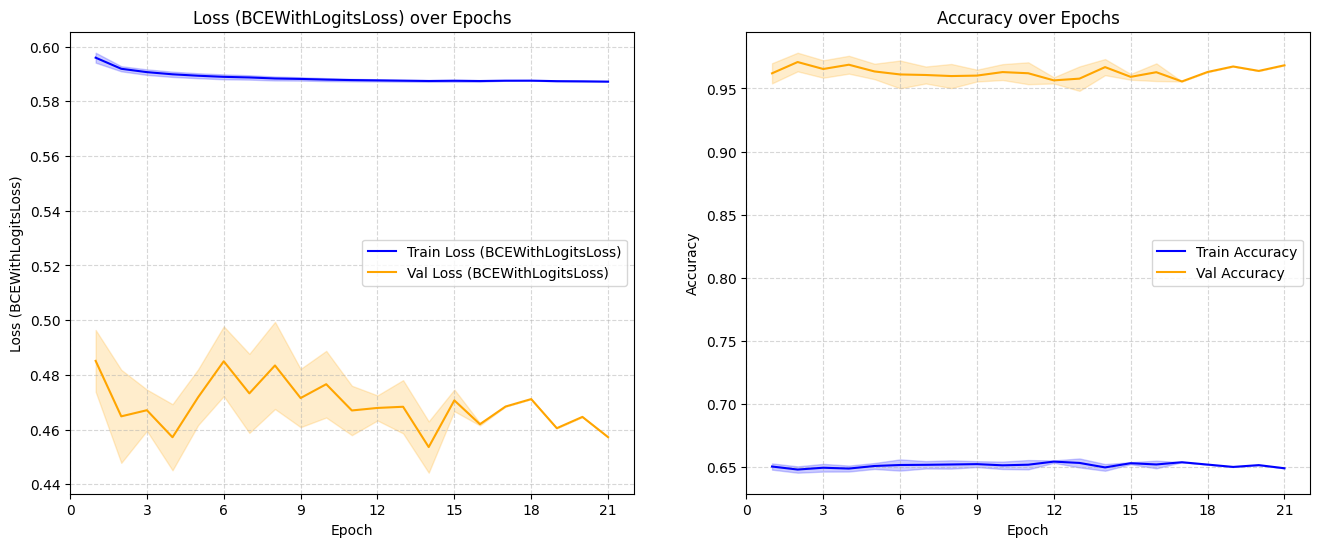

In [14]:
sage_model = SAGEModel(
    data=data,
    col_stats_dict=col_stats_dict,
    in_channels=in_channels,
    gnn_config=config["gnn_heads"]["sage"],
    mlp_config=mlp_config,
    task_type=task_type,
    dropout=dropout
).to(device)

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))
optimizer = torch.optim.AdamW(sage_model.parameters(), lr=learning_rate)

trainer = Trainer(
    task,
    sage_model,
    optimizer,
    criterion,
    device
)

trainer.run_experiment(
    loader_dict,
    num_epochs,
    tune_metric="accuracy",
    higher_is_better=True,
    patience=10,
    print_every=3,
    num_runs=num_runs
)

# torch.save(best_weights, os.path.join(cache_dir, dataset_name, f"{sage_model.gnn_name}_{task_name}_best_weights.pt"))

del sage_model, optimizer, trainer
torch.cuda.empty_cache()
gc.collect()

## HGT


MODEL INFO:
Model name: HGT
Number of parameters: 2264625


STARTING RUN 1/5


Evaluating: 100%|██████████| 528/528 [00:04<00:00, 107.41it/s]


Epoch 1/30 | Train Loss: 0.6110 | Train accuracy: 0.6433
Epoch 1/30 |   Val Loss: 0.4813 |   Val accuracy: 0.9792
New best model found with Val accuracy: 0.9792


Evaluating: 100%|██████████| 528/528 [00:04<00:00, 108.11it/s]


New best model found with Val accuracy: 0.9814


...

Evaluating: 100%|██████████| 528/528 [00:05<00:00, 88.47it/s]


!!! No improvement in Val accuracy for 10 epochs (Early stopping at epoch 16) !!!


Evaluating: 100%|██████████| 569/569 [00:06<00:00, 93.45it/s]


Run 5/5 | Final Train Metrics: {'accuracy': 0.6335033246749947, 'roc_auc': 0.7016313163151479, 'average_precision': 0.5475372248721733, 'f1': 0.0, 'loss': 0.5948002885766449}
Run 5/5 | Final Val Metrics: {'accuracy': 0.9868321712483901, 'roc_auc': 0.7352432545394105, 'average_precision': 0.10241272525979045, 'f1': 0.0, 'loss': 0.454000427765955}
Run 5/5 | Final Test Metrics: {'accuracy': 0.987563470959674, 'roc_auc': 0.7440115931036422, 'average_precision': 0.1042829525880339, 'f1': 0.0, 'loss': 0.4538102064204836}
FINISHED RUN 5/5


FINAL STATS OVER 5 RUNS

[TRAIN] Metrics:
  Accuracy: 0.6335 ± 0.0000
  Roc_auc: 0.7004 ± 0.0015
  Average_precision: 0.5461 ± 0.0016
  F1: 0.0000 ± 0.0000
  Loss: 0.5978 ± 0.0024

[VAL] Metrics:
  Accuracy: 0.9868 ± 0.0000
  Roc_auc: 0.7348 ± 0.0010
  Average_precision: 0.1174 ± 0.0115
  F1: 0.0000 ± 0.0000
  Loss: 0.4656 ± 0.0076

[TEST] Metrics:
  Accuracy: 0.9876 ± 0.0000
  Roc_auc: 0.7432 ± 0.0010
  Average_precision: 0.1193 ± 0.0114
  F1: 0.0000 ± 0.

21

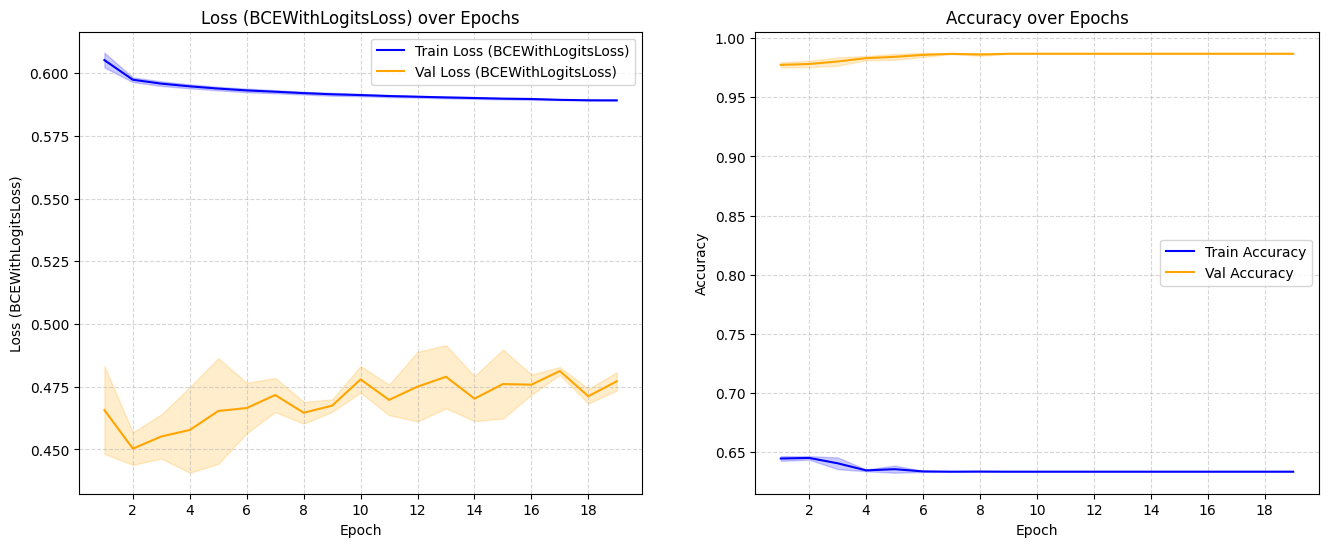

In [14]:
hgt_model = HGTModel(
    data=data,
    col_stats_dict=col_stats_dict,
    in_channels=in_channels,
    gnn_config=config["gnn_heads"]["hgt"],
    mlp_config=mlp_config,
    task_type=task_type,
    dropout=dropout
).to(device)

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))
optimizer = torch.optim.AdamW(hgt_model.parameters(), lr=learning_rate)

trainer = Trainer(
    task=task,
    model=hgt_model,
    optimizer=optimizer,
    criterion=criterion,
    device=device
)

trainer.run_experiment(
    loader_dict,
    num_epochs,
    tune_metric="accuracy",
    higher_is_better=True,
    patience=10,
    print_every=3,
    num_runs=num_runs
)

# torch.save(best_weights, os.path.join(cache_dir, dataset_name, f"{hgt_model.gnn_name}_{task_name}_best_weights.pt"))

del hgt_model, optimizer, trainer
torch.cuda.empty_cache()
gc.collect()